# Sc3 SOCIO — Circular Economy and Grid Decarbonisation
Low steel intensity (L=8), high scrap collection (95%), 40% H-DRI by 2050 driven by policy, substantially decarbonised grid. Current electrolyzer technology.

In [2]:
import sys
sys.path.append('..')  # adjust if model_functions.py is elsewhere
from model_functions import run_scenario

## Parameters

In [ ]:
params = {
    "L": 8.0,
    "scrap_end": 0.95,
    "dri_share_2050": 0.4,
    "grid_co2": 80,
    "eaf_efficiency": 470,
    "h2_conversion": 60,
    "aec_share": 0.55,
    "pem_share": 0.35,
    "other_share": 0.1,
    "lifetime_AEC": 90000,
    "lifetime_PEM": 70000,
    "lifetime_Other": 45000,
    "efficiency_AEC": 50.0,
    "efficiency_PEM": 55.0,
    "efficiency_Other": 43.4,
    "nickel_intensity": 800,
    "platinum_intensity": 0.5,
    "iridium_intensity_2022": 0.67,
    "iridium_intensity_2030": 0.3,
    "iridium_intensity_2050": 0.1,
}

## Run model

In [4]:
results = run_scenario(params, scenario_name='03_socio')


Running scenario: 03_socio


c:\Users\ovid\MasterThesis\master\electrolysers\raw_processing\model_functions.py:72: DtypeWarning: Columns (2,3,4,7) have mixed types. Specify dtype option on import or set low_memory=False.
  future_pop_data = pd.read_csv(pop_folder / 'future_population.csv')


Stock 2008: 25.72 Gt
Stock 2050: 52.81 Gt
  Primary steel 2050:  656 Mt
  DRI production 2050: 256 Mt  (39% of primary)
  H2 demand 2050:      15.34 Mt
  CO2 total 2050:      1081 Mt
  Ni inflow 2050:      3.40 kt
  Ir inflow 2050:      1.91 t
  Saved → C:\Users\ovid\MasterThesis\master\electrolysers\data\processed\03_socio.pkl


## Quick sanity check

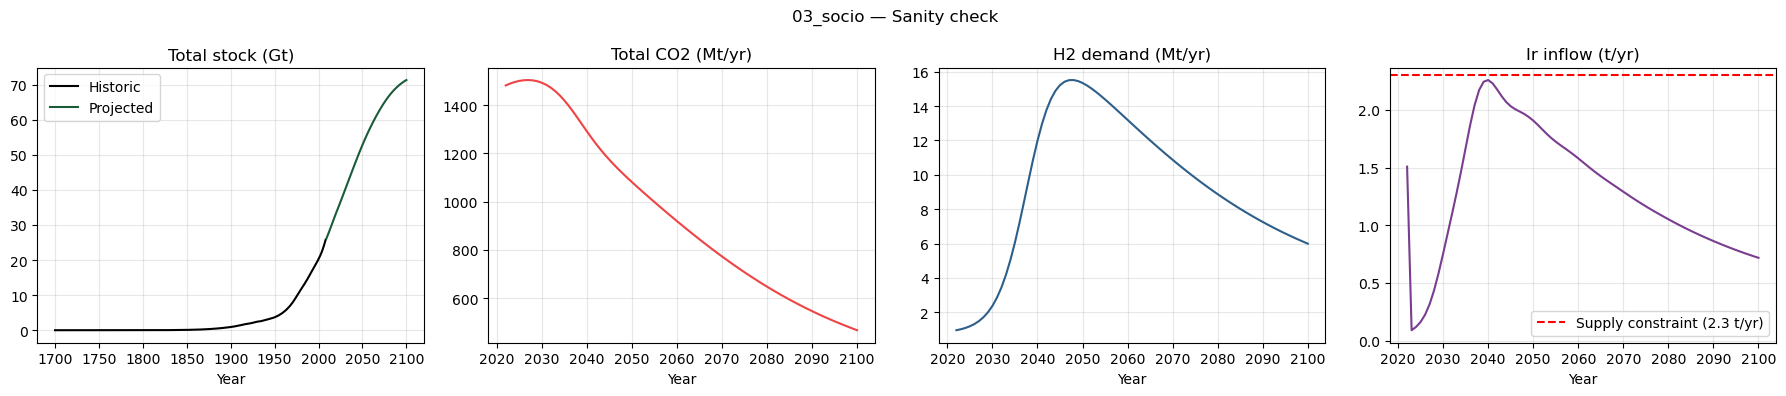

In [5]:
import matplotlib.pyplot as plt
import numpy as np

years     = results['years']
plot_years = results['plot_years']
future    = results['future']
prod      = results['production']
em        = results['emissions']
h2        = results['h2']
mats      = results['materials']

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle(f"{results['scenario_name']} — Sanity check", fontsize=12)

# Total steel
hist = results['stock_df'][results['stock_df']['type']=='historic']
pred = results['stock_df'][results['stock_df']['type'].isin(['recent','predicted'])]
axes[0].plot(hist['year'], hist['total_stock']/1e9, color='black', label='Historic')
axes[0].plot(pred['year'], pred['total_stock']/1e9, color='#1a5c3a', label='Projected')
axes[0].set_title('Total stock (Gt)'); axes[0].legend(); axes[0].grid(alpha=0.3)

# Emissions
axes[1].plot(plot_years, em['Total Emissions'], color='#ef4444')
axes[1].set_title('Total CO2 (Mt/yr)'); axes[1].grid(alpha=0.3)

# H2 demand
axes[2].plot(plot_years, h2['H2 Demand (Mt)'], color='#2e5f8a')
axes[2].set_title('H2 demand (Mt/yr)'); axes[2].grid(alpha=0.3)

# Iridium
axes[3].plot(years, mats['iridium_inflow']*1000, color='#7a3d8f')
axes[3].axhline(2.3, linestyle='--', color='red', label='Supply constraint (2.3 t/yr)')
axes[3].set_title('Ir inflow (t/yr)'); axes[3].legend(); axes[3].grid(alpha=0.3)

for ax in axes:
    ax.set_xlabel('Year')
plt.tight_layout()
plt.show()